# Running Starlight

In [34]:
import os
import re
import glob
import copy
import numpy as np 
from astropy.io import fits
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image
from scipy.ndimage import label
import matplotlib as mpl


Now, some functions that we need for the next steps:

In [2]:
def wavelength_axis(header, axis=3):
    """
    Calculate the wavelength axis for a given FITS header.

    Parameters:
    header (astropy.io.fits.Header): FITS header containing wavelength calibration keywords.
    axis (int): The axis number for which to calculate the wavelength array. Default is 3.

    Returns:
    numpy.ndarray: Calculated wavelength values for the specified axis.
    """
    # Get reference pixel, value, and increment from the header
    crpix = header[f'CRPIX{axis}']
    crval = header[f'CRVAL{axis}']
    cdelt = header[f'CD3_{axis}']
    #cdelt = header[f'CDELT{axis}']
    naxis = header[f'NAXIS{axis}']
    
    # Create an array of pixel indices
    index = np.arange(naxis)
    
    # Calculate and return the wavelength values
    return crval + (index + 1 - crpix) * cdelt

In [3]:
def save_spectrum_txt(galaxy_name, wave, redshift, hdul, out_dir):
    """
    Extracts the spectrum of each spaxel from a data cube and saves it as an
    individual text file.

    The observed wavelength axis is converted to the rest frame using the
    galaxy redshift. Each spectrum is interpolated onto a linear wavelength
    grid with a sampling of 1 Å. Any NaN values resulting from the
    interpolation are replaced with zeros before saving.

    Parameters
    ----------
    galaxy_name : str
        Name of the galaxy, used as the prefix for the output filenames.
    wave : ndarray
        Observed wavelength array.
    redshift : float
        Galaxy redshift used to compute the rest-frame wavelength.
    hdul : astropy.io.fits.HDUList
        FITS file containing the spectral data cube.
    out_dir : str
        Directory where the output text files will be saved.

    Notes
    -----
    - Each output file contains two columns: rest-frame wavelength (Å) and
      interpolated flux.
    - Existing files are skipped to avoid redundant processing.
    - A reference spaxel is plotted for visual inspection of the rest-frame
      correction.
    - Spectra containing only NaN values are identified separately.
    """
    sci = hdul[0].data
    
    nz, ny, nx = sci.shape

    rest_wave = wave / (1 + redshift)

    count = 0
    for y in range(ny):
        for x in range(nx):
            # Nome do arquivo
            filename = f"{galaxy_name}_{y}_{x}.txt"
            filepath = os.path.join(out_dir, filename)

            if os.path.exists(filepath):
                #print(f"File {filename} already exists. Skipping...")
                continue

            flux = sci[:, y, x]


            # Cria novo eixo de comprimento de onda com passo de 1 Å
            wavelength_linear = np.arange(np.ceil(rest_wave.min()), np.floor(rest_wave.max()) + 1, 1)

            # Interpola o fluxo
            interp_flux = interp1d(rest_wave, flux, kind='linear', bounds_error=False, fill_value="extrapolate")

            flux_linear = interp_flux(wavelength_linear)

            onde_tem_nan = np.where(np.isnan(flux_linear))
            flux_linear[onde_tem_nan] = 0

            # Organiza em colunas
            data = np.column_stack((wavelength_linear, flux_linear))#, error_linear))

            # faz um plot de um spaxel qualquer, para conferir seo espectro está no repouso
            if y == 25 and x == 15:
                plt.plot(wavelength_linear, flux_linear)
                plt.xlabel("Wavelength (Å)")
                plt.ylabel("Flux")
                plt.title(f"Interpolated Spectrum at ({x}, {y}) for {galaxy_name}")
                plt.show()


            # Salva como texto com cabeçalho
            np.savetxt(filepath, data, fmt="%.6e", comments='')

            if np.isnan(flux).all():
                print(f"NaN values found in {filename}")
                new_file_path = os.path.join(out_dir, f"{galaxy_name}_{y}_{x}_CB19_16x5")
                np.savetxt(new_file_path, data, fmt="%.6e", comments='')
            else:
                count += 1

            #print(f"Arquivo salvo: {filepath}")

    print(f"Total de arquivos salvos: {count}")

The galaxy redshift:

In [4]:
redshifts = {
    '1_279073': 0.0323
}

Initial definitions:

In [5]:
galaxy_name = '1_279073'
fits_file = f"Manga_{galaxy_name}_pca.fits"


datapath =  Path.cwd().parent / "data"
starlight_dir = datapath / f"starlight/"

starlight_dir.mkdir(exist_ok=True)

redshift = redshifts[galaxy_name]

## Transforming data cube into text files for Starlight input

In [6]:
with fits.open(datapath / fits_file) as hdul:
    wave = wavelength_axis(hdul[0].header)

    sci = hdul[0].data
    
    nz, ny, nx = sci.shape

    rest_wave = wave / (1 + redshift)

    count = 0
    for y in range(ny):
        for x in range(nx):
            # Nome do arquivo
            filename = f"{galaxy_name}_{y}_{x}.txt"
            filepath = os.path.join(starlight_dir, filename)

            if os.path.exists(filepath):
                #print(f"File {filename} already exists. Skipping...")
                continue

            flux = sci[:, y, x]


            # Cria novo eixo de comprimento de onda com passo de 1 Å
            wavelength_linear = np.arange(np.ceil(rest_wave.min()), np.floor(rest_wave.max()) + 1, 1)

            # Interpola o fluxo
            interp_flux = interp1d(rest_wave, flux, kind='linear', bounds_error=False, fill_value="extrapolate")

            flux_linear = interp_flux(wavelength_linear)

            onde_tem_nan = np.where(np.isnan(flux_linear))
            flux_linear[onde_tem_nan] = 0

            # Organiza em colunas
            data = np.column_stack((wavelength_linear, flux_linear))#, error_linear))

            # faz um plot de um spaxel qualquer, para conferir seo espectro está no repouso
            if y == 25 and x == 15:
                plt.figure(figsize=(20,5))
                plt.plot(wavelength_linear, flux_linear, '-k')
                plt.plot([6300,6300], [0.06, 0.1], 'C0')
                plt.xlabel("Wavelength (Å)")
                plt.ylabel("Flux")
                plt.title(f"Interpolated Spectrum at ({x}, {y}) for {galaxy_name}")
                plt.tight_layout()
                plt.savefig(datapath / f'{galaxy_name}_{y}_{x}_flux.png')
                plt.show()


            # Salva como texto com cabeçalho
            np.savetxt(filepath, data, fmt="%.6e", comments='')

            if np.isnan(flux).all():
                print(f"NaN values found in {filename}")
                new_file_path = os.path.join(starlight_dir, f"{galaxy_name}_{y}_{x}_CB19_16x5")
                np.savetxt(new_file_path, data, fmt="%.6e", comments='')
            else:
                count += 1

            #print(f"Arquivo salvo: {filepath}")

    print(f"Total de arquivos salvos: {count}")

Total de arquivos salvos: 0


Now, we need to create the input list for Starlight.

In [7]:
output_list = datapath / f"{galaxy_name}_starlight_input_list.txt"
extension = ".txt" 

gmos = True

# choose a library
if gmos:
    library = 'XSL'
    mask = "mask_gmos_workshop.gm"
    if library == 'EMILES_Padova_240':
        template = 'base_EMILES_Padova_KU_all_ages.txt'
    elif library == 'EMILES_Padova_38':
        template = 'base_EMILES_Padova_KU_SafeRanges_for_IR.txt'
    elif library == 'EMILES_Basti_120':
        template = 'base_EMILES_Basti_KU_SafeRanges_for_IR.txt'
    elif library == 'EMILES_Basti_250':
        template = 'base_EMILES_Basti_KU_all_ages_gt_0pt06.txt'
    elif library == 'CB19_16x5':
        template = "CBASE.PARSEC.chab.16x5.all"
    elif library == 'XSL':
        template = 'base_XSL_Kroupa_PC_AGN_LLAMA.txt'

# Componentes fixos
fixos = ["StCv04.C11.config", template, 
         mask, "CCM", "0.0", "150.0"]


with output_list.open("w") as f:
    for file in sorted(starlight_dir.glob("*" + extension)):
        file_name = file.stem  # nome do arquivo sem extensão
        out_name = f"{file_name}_{library}"
        #print(out_name)

        if out_name in os.listdir(starlight_dir):
            continue
        linha = f"{file.name}  {'  '.join(fixos)}  {out_name}"
        f.write(linha + "\n")


Now, you need to edit our starlight input file, and add the items from the list **{galaxy_name}_starlight_input_list.txt** into **.in** file.



The **.in** file header is the following:

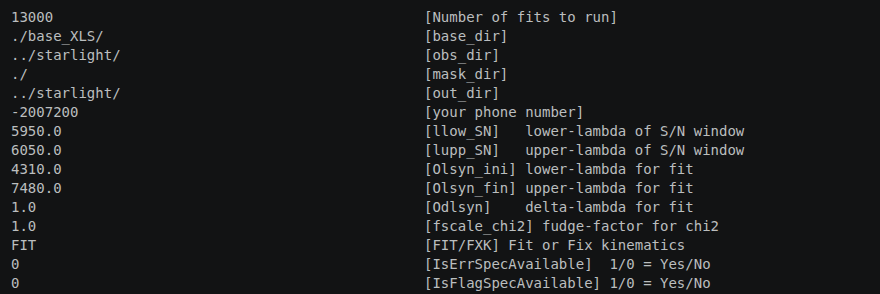

In [8]:
Image("../data/input_screenshot.png")

Before actually run starlight, you need to check if all the paths are correct. 

I suggest that you add the **.in** and the mask file **.gm** inside the starlight directory where the executable is. 

To run starlight, we need to go to the right directory:

In [9]:
%pwd
%cd ..
%cd data/STARLIGHTv04/

/home/kelly/git/spectroscopy-workshop
/home/kelly/git/spectroscopy-workshop/data/STARLIGHTv04


Running starlight:

In [10]:
import subprocess

subprocess.run(
    "./StarlightChains_v04.exe < cube.in",
    shell=True,
    check=True,
)


**> Welcome to STARLIGHT (v04) & good luck with this run!

**> Read config file: StCv04.C11.config                                                                                   
**> Read data file: 1_279073_26_13.txt            
    from dir = ./base_XLS/  
    Data goes from:   4179.0  -->   7245.0 Angs with N =  3067 pixels
**> ATT: Defined error & flag spectra the old way! S/N =   28.645
**> Read base files: base_XSL_Kroupa_PC_AGN_LLAMA.txt              N_base  = 100
    from dir = ./base_XLS/
**> Read masks file: mask_gmos_workshop.gm                         N_masks =   8
    from dir = ./
**> Modeling 1_279073_26_13.txt             ==> 1_279073_26_13_XSL                                                                                  
    Sampling: 4310.0 ==> 7480.0  with dl =   1.0 Angs  & fscale_chi2 = 1.000E+00
    dl_cushion (A) =   50.0
    Extinction Law = CCM
    Initial kinematical parameters: v0 =    0.0 & vd =  150.0 km/s
    We are going to FIT the spectrum of this

CompletedProcess(args='./StarlightChains_v04.exe < cube.in', returncode=0)

**Now, we need to check if the fit is good.**

But, first, a function that reads the starlight output file:

In [11]:
def read_starlight_output(file: str, filepath: str) -> dict:
    """
    Parse and extract information from STARLIGHT output files.

    This function reads one or more STARLIGHT output files, extracting both
    metadata and synthetic spectrum information. For each galaxy (identified
    by the prefix of the filename), the function stores:
    
    - Metadata key-value pairs parsed from lines in the format `value [description]`.
    - Synthetic spectrum data, including wavelength, observed flux, model flux,
      and weights.

    Parameters
    ----------
    files : list of str
        List of STARLIGHT output filenames to be read.
        Each filename is expected to start with the galaxy name
        (e.g., ``NGC1234_output.txt`` → galaxy name = ``NGC1234``).
    filepath : str
        Path to the directory containing the STARLIGHT output files.

    Returns
    -------
    dict
        A nested dictionary with the following structure:
        
        {
            galaxy_name: {
                'metadata': dict
                    Key-value pairs extracted from the header section.
                'wavelenght': list of float
                    Wavelength values of the synthetic spectrum.
                'f_obs': list of float
                    Observed flux values.
                'f_model': list of float
                    Model flux values.
                'weight': list of float
                    Weights associated with each wavelength point.
            },
            ...
        }
    """

    results_all = {}
    reading_spectrum = False

    metadata = {}
    lamb, f_obs, f_model, weight = [], [], [], []

    with open(str(filepath)+str(file), 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

        if lines[0].startswith("#"):

            for idx, line in enumerate(lines):
                line = line.strip()
    
                match = re.match(r'^(.*?)\[(.*)\]', line)
                if match:
                    raw_values, description = match.groups()
                    raw_values = raw_values.strip()
                    description = description.strip()
            
                    values = raw_values.split()
                    if len(values) == 1:
                        value = values[0]  # valor único como string
                    else:
                        value = values  # lista de strings
            
                    metadata[description] = value
    
                elif line.startswith('## Synthetic spectrum '):  # Início dos espectros # elif line:  # Início dos espectros
                    reading_spectrum = True
                    continue
                
                elif reading_spectrum:
                    parts = line.split()
                    if len(parts) == 4:
                        spectrum = list(map(float, parts))
                        lamb.append(spectrum[0])
                        f_obs.append(spectrum[1]) #* 10**-17  # Convertendo para erg/s/cm²/Å
                        f_model.append(spectrum[2]) #* 10**-17  # Convertendo para erg/s/cm²/Å
                        weight.append(spectrum[3])  # is 1/error 
                    else:
                        reading_spectrum = False  # Parar de ler se a linha mudar o formato
                    continue  # Já tratou essa linha, então pula pro próximo loop

        if not lines[0].startswith("#"):
            wave_fixo = np.arange(4310, 7300 + 1, step=1)
            nwave = len(wave_fixo)
            model = np.zeros(nwave)
            #print(nwave, model)

            #for i in lines:
            #lamb.append(wave_fixo)
            #f_obs.append(model)
            #f_model.append(model)
            #weight.append(model)

    if not metadata:
        #print(f"Warning: No metadata found in file {file}. Using default values.")
        #print(min(np.array(lamb)), max(np.array(lamb)))
        results_all['chi2']     = 0
        results_all['adev']     = 0
        results_all['AV_min']   = 0
        results_all['flux_tot'] = 0
        results_all['Mini_tot'] = 0
        results_all['Mcor_tot'] = 0
        results_all['v0_min']   = 0
        results_all['vd_min']   = 0
        results_all['q_norm']   = 0
        results_all['fobs_norm']= 0
        results_all['l_ini']    = 0
        results_all['dl']       = 0

        results_all['wavelength']   = wave_fixo
        results_all['observed']     = model
        results_all['stellar']      = model
        results_all['gas']          = model
        results_all['weight']       = model

    elif metadata:
        #print(min(np.array(lamb)), max(np.array(lamb)))

        
        results_all['chi2']     = float(metadata.get('chi2/Nl_eff'))
        results_all['adev']     = float(metadata.get('adev (%)'))
        results_all['AV_min']   = float(metadata.get('AV_min  (mag)'))
        results_all['flux_tot'] = float(metadata.get('Flux_tot (units of input spectrum!)'))
        results_all['Mini_tot'] = float(metadata.get('Mini_tot (???)') )
        results_all['Mcor_tot'] = float(metadata.get('Mcor_tot (???)') )
        if metadata.get('v0_min  (km/s)').startswith('*'):
            results_all['v0_min'] = np.nan
        else:
            results_all['v0_min']   = float(metadata.get('v0_min  (km/s)'))
        results_all['vd_min']   = float(metadata.get('vd_min  (km/s)'))
        results_all['q_norm']   = float(metadata.get('q_norm = A(l_norm)/A(V)'))
        results_all['fobs_norm']= float(metadata.get('fobs_norm (in input units)'))
        results_all['l_ini']    = float(metadata.get('l_ini (A)'))
        results_all['dl']       = float(metadata.get('dl    (A)'))

        fobs_norm = metadata.get('fobs_norm (in input units)')

        results_all['wavelength']   = np.array(lamb) 
        results_all['observed']     = np.array(f_obs)  * float(fobs_norm)
        results_all['stellar']      = np.array(f_model) * float(fobs_norm)
        results_all['gas']          = np.array(np.array(results_all['observed']) - np.array(results_all['stellar']))
        results_all['weight']       = np.array(weight) * float(fobs_norm)


    return results_all

In [12]:
%cd ~/git/spectroscopy-workshop/data/

/home/kelly/git/spectroscopy-workshop/data


In [13]:
print(os.getcwd())

/home/kelly/git/spectroscopy-workshop/data


Processing /home/kelly/git/spectroscopy-workshop/data/starlight/1_279073_26_16_XSL...


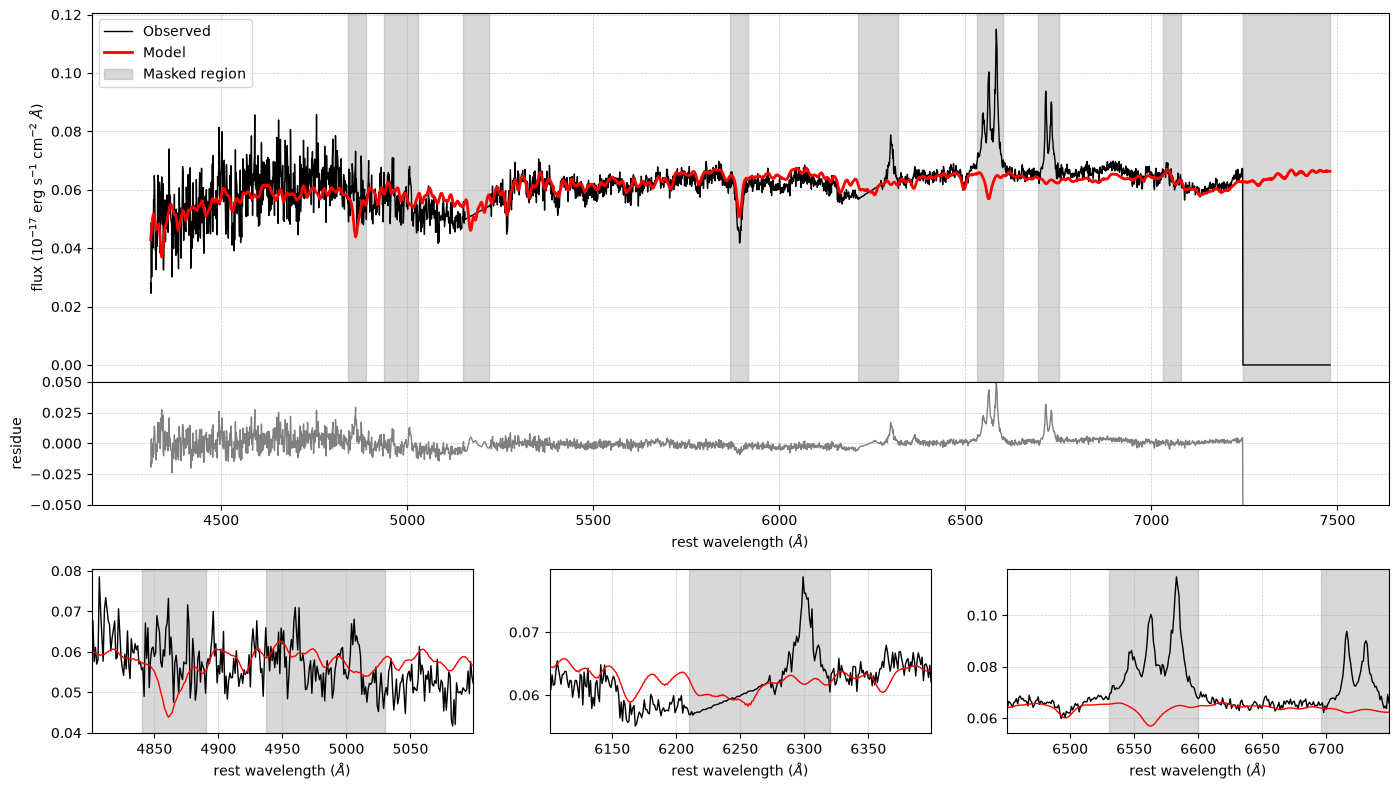

Processing /home/kelly/git/spectroscopy-workshop/data/starlight/1_279073_26_13_XSL...


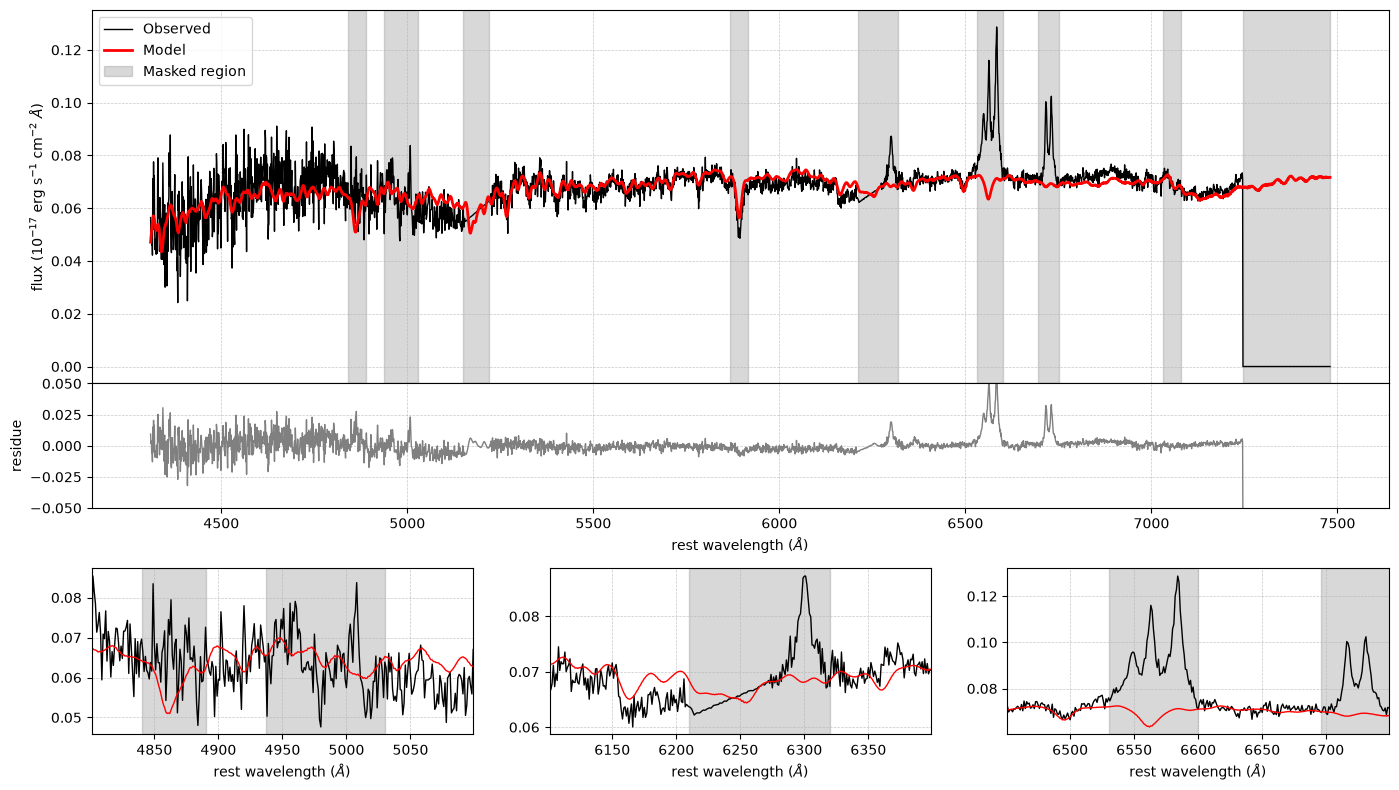

Processing /home/kelly/git/spectroscopy-workshop/data/starlight/1_279073_26_14_XSL...


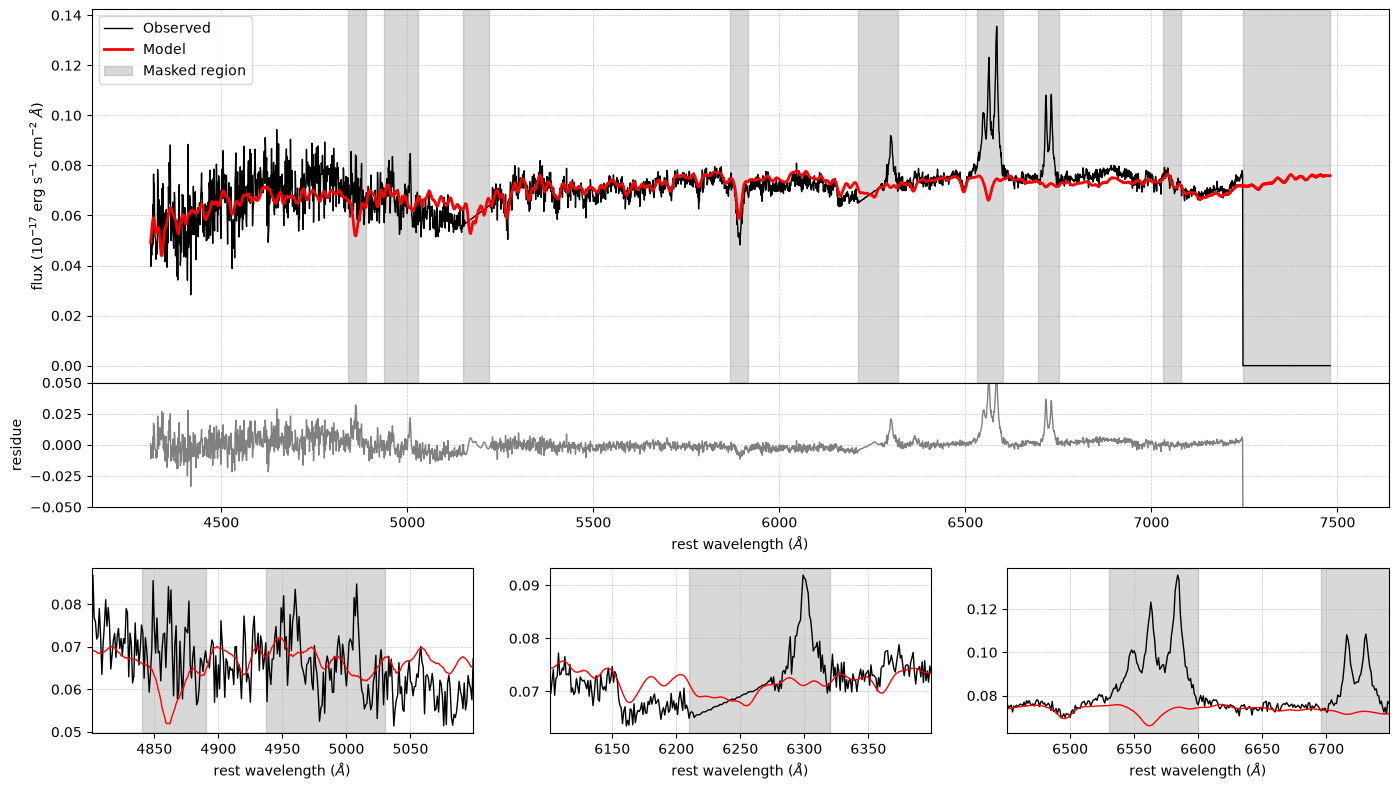

Processing /home/kelly/git/spectroscopy-workshop/data/starlight/1_279073_26_17_XSL...


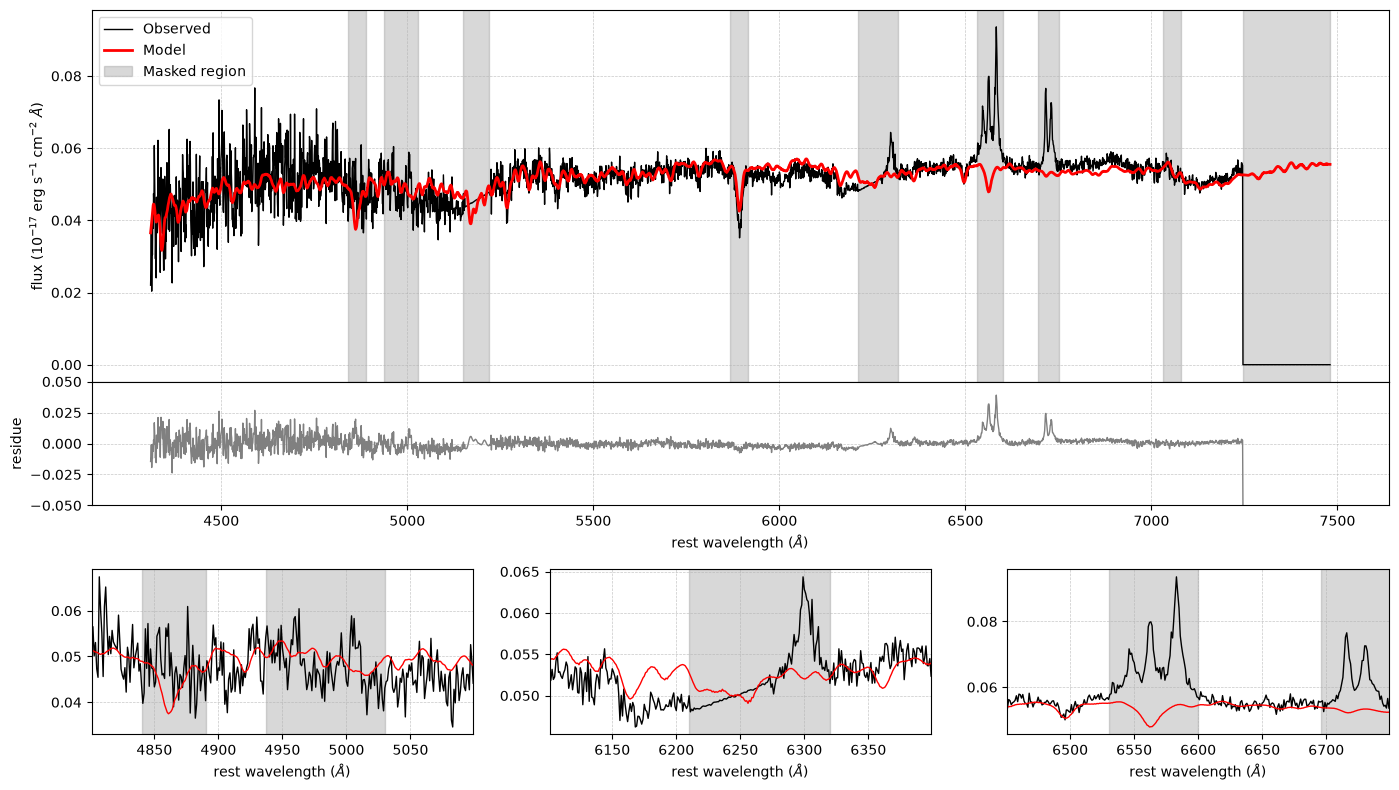

Processing /home/kelly/git/spectroscopy-workshop/data/starlight/1_279073_26_15_XSL...


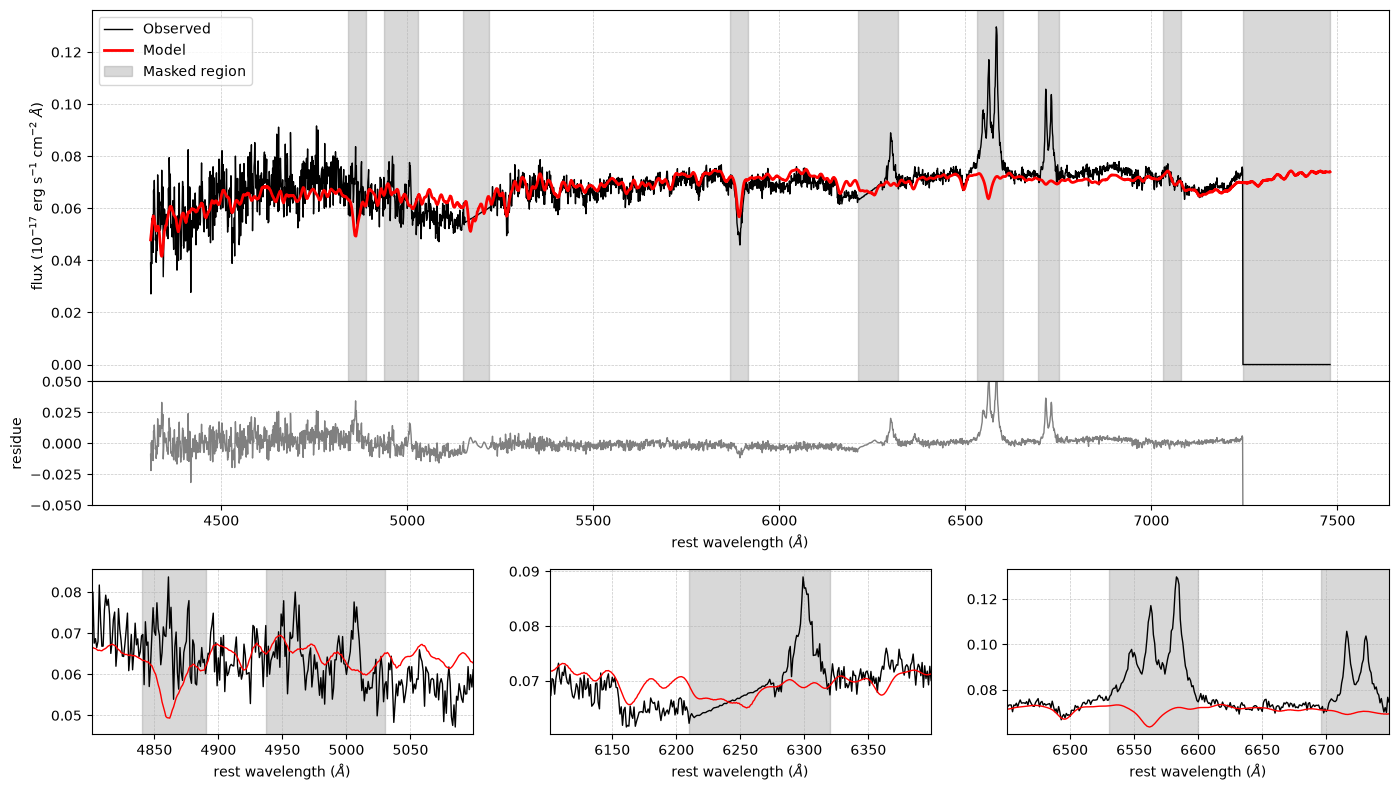

In [25]:
starlight_files = glob.glob(os.getcwd() + f'/starlight/*XSL')
#print(starlight_files)
for arq in starlight_files:
    if arq+'_starlight.png' in os.listdir(starlight_dir):
        continue

    print(f'Processing {arq}...')

    result = read_starlight_output(arq, '')

    wave    = result['wavelength']
    f_obs   = result['observed']
    f_model = result['stellar']
    gas     = result['gas']
    weight  = result['weight']

    limits_list = [(wave > 4800) & (wave < 5100), (wave > 6100) & (wave < 6400), (wave > 6450) & (wave < 6750)]

    # Identify emission line intervals
    w0      = np.array(weight) <= 0
    labels, num_features = label(w0)

    intervals = []
    for i in range(1, num_features + 1):
        indices = np.where(labels == i)[0]
        inicio = wave[indices[0]]
        fim = wave[indices[-1]]
        intervals.append((inicio, fim))


    fig = plt.figure(figsize=(14, 8))

    gd = mpl.gridspec.GridSpec(2, 1, figure=fig, height_ratios=[3, 1])
    gs_top = mpl.gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gd[0], height_ratios=[3, 1], hspace=0)

    ax_top = fig.add_subplot(gs_top[0, :])
    ax_bottom = fig.add_subplot(gs_top[1, :], sharex=ax_top)

    # Principal plot
    ax_top.plot(wave, f_obs, label='Observed', lw=1, color='k')
    ax_top.plot(wave, f_model, label='Model', lw=2, color='r')
    ax_top.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    for  i, (inicio, fim) in enumerate(intervals):
        labels = 'Masked region' if i == 0 else None
        ax_top.axvspan(inicio, fim, color='gray', alpha=0.3, label=labels)
    ax_top.legend()
    #ax_top.set_ylim(0, 0.2)

    ax_top.set_ylabel(r'flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA$)')

    # Observed - stellar
    ax_bottom.plot(wave, gas, lw=1, color='gray')
    ax_bottom.set_ylabel('residue')
    ax_bottom.set_ylim(-0.05, 0.05)
    ax_bottom.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax_bottom.set_xlabel(r'rest wavelength ($\AA$)')


    gs_bot = mpl.gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gd[1])

    for i, limit in enumerate(limits_list):
        
        ax = fig.add_subplot(gs_bot[i])
        ax.plot(wave[limit], f_obs[limit], label='Observed', lw=1, color='k' )
        ax.plot(wave[limit], f_model[limit], label='Model', lw=1, color='r')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_xlabel(r'rest wavelength ($\AA$)')
        xmin = wave[limit].min() 
        xmax = wave[limit].max() 
        ax.set_xlim(xmin, xmax)           
        for  i, (inicio, fim) in enumerate(intervals):
            labels = 'Masked region' if i == 0 else None
            ax.axvspan(inicio, fim, color='gray', alpha=0.3, label=labels)

        if i == 0:
            # ax.legend()
            ax.set_ylabel(r'flux (10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA$)')


    fig.tight_layout()
    plt.savefig(f'{arq}_starlight.png')
    plt.show()
    #plt.close(fig)


    #del fig, result


After checking the fits, we can, now, redo the data cube for the next steps (or not).

In [15]:
def safe_float(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

This object has no good signal-to-noise outside the nuclear region, as can be seen by the singular spectra. So, we need to select a criteria to mask the bad regions. 

We choose to define as nan all the regions that have v0 > 100 km/s.

In [31]:
starlight_files = glob.glob(os.getcwd() + f'/starlight_old/*XSL')

datacube = fits.open(datapath / fits_file)

header = datacube[0].header
data = datacube[0].data
nz = data.shape[0]
nx, ny = data.shape[2], data.shape[1]  # salva as dimensões espaciais
sl = datacube[0].header['crpix1']

example = read_starlight_output(starlight_files[0], '')
wave = example['wavelength']
nwave = len(wave)
wave_min = wave[0]
wave_max = wave[-1]
print(f'wave min: {wave_min}, wave max: {wave_max}')


cubo     = np.full((nwave, ny, nx), np.nan)
observed = np.full((nwave, ny, nx), np.nan)
stellar  = np.full((nwave, ny, nx), np.nan)
gas      = np.full((nwave, ny, nx), np.nan)
weight   = np.full((nwave, ny, nx), np.nan)
stellar_velocity    = np.full((ny, nx), np.nan)
stellar_dispersion  = np.full((ny, nx), np.nan)
av_min              = np.full((ny, nx), np.nan)
chi2                = np.full((ny, nx), np.nan)



cnt         = np.nanmedian(data[1000:1500,:,:], axis=0)
arr2D   = cnt.copy()
arr2D   = arr2D / np.nanmean(arr2D) # para trabalhar com numeros menores, o ideal seria ser magnitudes
resultado  = np.where(arr2D == np.amax(arr2D))
print(resultado)
ycen = resultado[0][0]
xcen = resultado[1][0]
print(xcen,ycen)
ycen = round(ycen)
xcen = round(xcen)#

# calcular a distancia a partir do nucleo
rad = data[0,:,:] * 0.0
nx  = len(rad[0,:])
ny  = len(rad[:,0])
for i in range(0,nx):
    for j in range(0,ny):
        rad[j,i] = ((j - ycen)**2 + (i - xcen)**2)**0.5 * sl




rows = []
for arq in starlight_files:
    #print(arq)
    nome = arq.split("/")[-1]
    partes = nome.split("_")
    y = int(partes[2])
    x = int(partes[3])

    result = read_starlight_output(arq, '')
    #print(type(result['v0_min']))
    #break

    #if abs(result['v0_min']) < 50:
        
    gas[:, y, x]        = result['gas']
    observed[:, y, x]   = result['observed']
    weight[:, y, x]     = result['weight']
    stellar[:, y, x]    = result['stellar']
    stellar_velocity[y, x]   = result['v0_min']
    stellar_dispersion[y, x] = result['vd_min']
    av_min[y, x]             = result['AV_min']
    chi2[y, x]               = result['chi2']

    gas[:,(rad > 2.5)] = np.nan
    observed[:,(rad > 2.5)] = np.nan
    weight[:,(rad > 2.5)] = np.nan
    stellar[:,(rad > 2.5)] = np.nan
    stellar_velocity[(rad > 2.5)] = np.nan
    stellar_dispersion[(rad > 2.5)] = np.nan
    av_min[(rad > 2.5)] = np.nan
    chi2[(rad > 2.5)] = np.nan





    rows.append((
        x, y,
        safe_float(result['chi2']),
        safe_float(result['adev']),
        safe_float(result['AV_min']),
        safe_float(result['flux_tot']),
        safe_float(result['Mini_tot']),
        safe_float(result['Mcor_tot']),
        safe_float(result['v0_min']),
        safe_float(result['vd_min']),
        safe_float(result['q_norm']),
        safe_float(result['fobs_norm']),
        safe_float(result['l_ini']),
        safe_float(result['dl'])
    ))


# converter tabela para structured array
dtype = [
    ('x', 'i4'), ('y', 'i4'),
    ('chi2', 'f8'), ('adev', 'f8'), ('AV_min', 'f8'),
    ('flux_tot', 'f8'), ('Mini_tot', 'f8'), ('Mcor_tot', 'f8'),
    ('v0_min', 'f8'), ('vd_min', 'f8'),
    ('q_norm', 'f8'), ('fobs_norm', 'f8'),
    ('l_ini', 'f8'), ('dl', 'f8')
]
table_data = np.array(rows, dtype=dtype)


cdelt = 1
crpix = 1
crval = wave[0]

header['NAXIS3']  = len(wave)
header['CRPIX3']  = crpix
header['CDELT3']  = cdelt
header['CD3_3']  = cdelt
header['CRVAL3']  = crval
header['CTYPE3']  = 'WAVE'


# salvar em FITS com múltiplas extensões
hdu0 = fits.PrimaryHDU()  # cabeçalho vazio
hdu1 = fits.ImageHDU(observed, header=header, name="OBSERVED")
hdu2 = fits.ImageHDU(stellar, header=header, name="STELLAR")
hdu3 = fits.ImageHDU(gas, header=header, name="GAS")
hdu4 = fits.ImageHDU(weight, header=header, name="WEIGHT")
hdu5 = fits.ImageHDU(stellar_velocity, header=header, name="STELLAR_VELOCITY")
hdu6 = fits.ImageHDU(stellar_dispersion, header=header, name="STELLAR_DISPERSION")
hdu7 = fits.ImageHDU(av_min, header=header, name="AV_MIN")
hdu8 = fits.ImageHDU(chi2, header=header, name="CHI2")
hdu_table = fits.BinTableHDU(table_data, name="PARAMS")

hdul = fits.HDUList([hdu0, hdu1, hdu2, hdu3, hdu4, hdu5, hdu6, hdu7, hdu8, hdu_table])
hdul.writeto(f"./Manga_{galaxy_name}_starlight.fits", overwrite=True)


wave min: 4310.0, wave max: 7480.0
(array([25]), array([14]))
14 25


Now, checking if the data cube is ok.

In [32]:
!ls

1_279073_25_15_flux.png			 Manga_1_279073_starlight.fits
1_279073_starlight_input_list_short.txt  starlight
1_279073_starlight_input_list.txt	 starlight_old
input_screenshot.png			 STARLIGHTv04
Manga_1_279073_pca.fits			 XLS


#### Let's see the continuum distribution and stellar kinematics maps

In [38]:
stel_file = fits.open('Manga_1_279073_starlight.fits')
stel_file.info()


continuum = stel_file['observed'].data
cnt         = np.nanmedian(continuum[1000:1500,:,:], axis=0)

v_stel = stel_file['stellar_velocity'].data
s_stel = stel_file['stellar_dispersion'].data

Filename: Manga_1_279073_starlight.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  OBSERVED      1 ImageHDU        69   (31, 43, 3171)   float64   
  2  STELLAR       1 ImageHDU        69   (31, 43, 3171)   float64   
  3  GAS           1 ImageHDU        69   (31, 43, 3171)   float64   
  4  WEIGHT        1 ImageHDU        69   (31, 43, 3171)   float64   
  5  STELLAR_VELOCITY    1 ImageHDU        69   (31, 43)   float64   
  6  STELLAR_DISPERSION    1 ImageHDU        69   (31, 43)   float64   
  7  AV_MIN        1 ImageHDU        69   (31, 43)   float64   
  8  CHI2          1 ImageHDU        69   (31, 43)   float64   
  9  PARAMS        1 BinTableHDU     37   1333R x 14C   [J, J, D, D, D, D, D, D, D, D, D, D, D, D]   


/tmp/ipykernel_100469/2967442815.py:6: RuntimeWarning: All-NaN slice encountered
  cnt         = np.nanmedian(continuum[1000:1500,:,:], axis=0)


In [37]:
# definicoes das figuras:
font = {'size': 13, 'family':'serif'} # 11
mpl.rc('font', **font)      # converte todas as fontes do grafico no estilo 'font'
font = font['size']
cmap1 = copy.copy(plt.cm.gist_heat) #plt.cm.gist_heat
cmap1.set_bad(color='gainsboro')
cmap2 =  copy.copy(plt.cm.jet) #plt.cm.jet
cmap2.set_bad(color='gainsboro')
cmap3 =  cmap1  #copy.copy(mpl.cm.get_cmap("inferno")) #plt.cm.inferno
cmap3.set_bad(color='gainsboro')
ext     = [-xcen*sl*(-1),-(len(cnt[0,:])-xcen)*sl,ycen*sl*(-1),(len(cnt[:,0])-ycen)*sl]


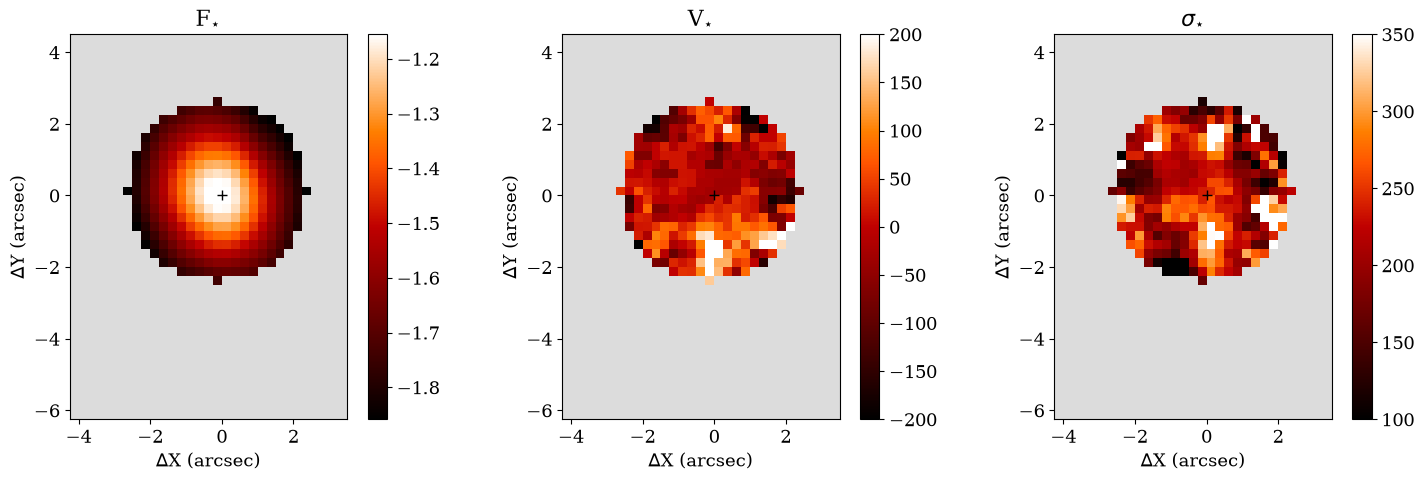

In [43]:
ax = plt.figure(figsize=(18, 5))  # 15, 5 para 3 paineis
xx, yy = 3, 1

vmin = -200
vmax = 200
smin = 100
smax = 350

count = 1
for i in range(1, 2, 1):

    plt.subplot(yy, xx, count)
    plt.title(r'F$_{\star }$')
    line    = np.log10(cnt)
    fi, ff  = np.nanpercentile([line], 2), np.nanpercentile([line], 98)
    cf      = np.linspace(fi, ff, num = 5)
    plt.imshow(line, cmap = cmap1,  
                origin = 'lower', extent = ext,
                vmin = fi, vmax = ff)
    plt.plot(0, 0, '+k', markersize = 7)
    plt.colorbar()
    #plt.colorbar(pad = pad, shrink = shrink, ticks = cf, format = "%03.1f")
    
    plt.gca().invert_xaxis()
    plt.xlabel(r'$\Delta$X (arcsec)')
    plt.ylabel(r'$\Delta$Y (arcsec)')


    count += 1
    plt.subplot(yy, xx, count )
    plt.title(r'V$_{\star}$')
    plt.imshow(v_stel, cmap = cmap1,
                 origin = 'lower', extent = ext,
                 vmin = vmin, vmax = vmax)
    plt.plot(0, 0, '+k', markersize = 7)
    plt.colorbar()

    plt.gca().invert_xaxis()
    plt.xlabel(r'$\Delta$X (arcsec)')
    plt.ylabel(r'$\Delta$Y (arcsec)')

    count += 1
    plt.subplot(yy, xx, count )
    plt.title(r'$\sigma_{\star}$')
    plt.imshow(s_stel, cmap = cmap1, 
                origin = 'lower', extent = ext,
                vmin = smin, vmax = smax)
    plt.plot(0, 0, '+k', markersize = 7)
    plt.colorbar()

    plt.gca().invert_xaxis()
    plt.xlabel(r'$\Delta$X (arcsec)')
    plt.ylabel(r'$\Delta$Y (arcsec)')


plt.show()
